In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset

# --! define known data properties
timeseries_len  = 200
timestep        = 0.001
dataset_dir     = 'cavity/train_embedding'
x_len           = 200 # 40 * 5

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
x_dims_n = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1


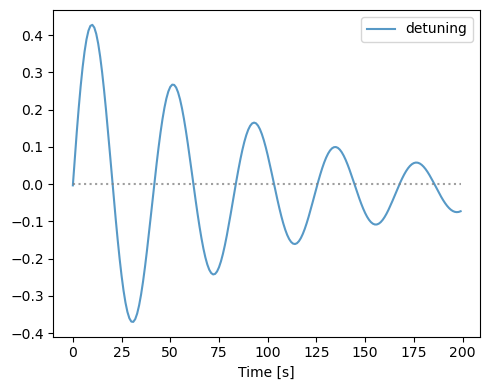

In [3]:
# --!--------------------------------------------------------------------------
# --! visualize individual data for double-checking

data_i = 9
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='detuning')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = care.detune()

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


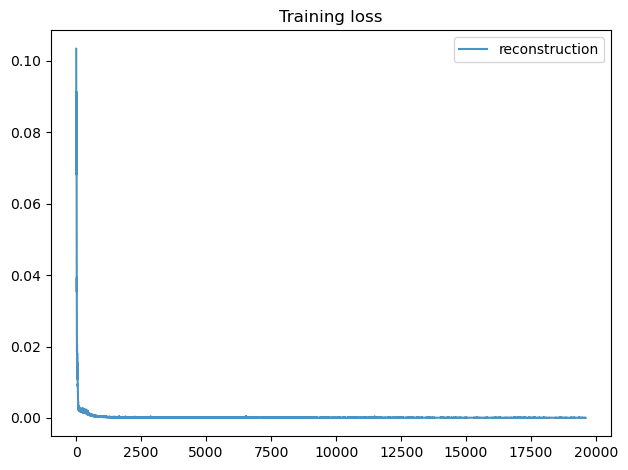

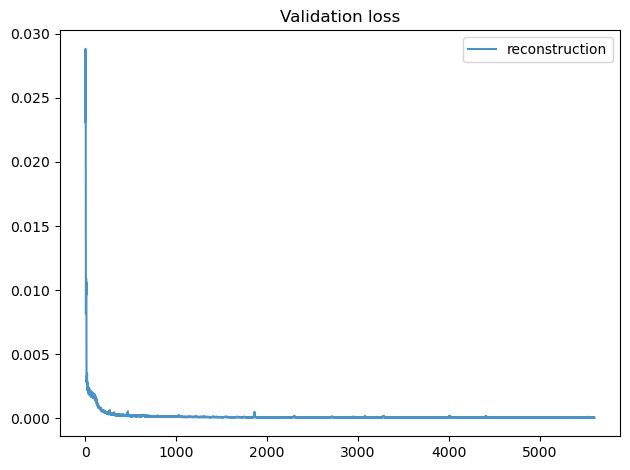

inf >> reconstruction loss in training is 2.561157e-04


In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation of the global Koopman operator

# --! as a sanity check, freeze everything except the encoder/decoder pair
utils.freeze_module(model.timeseries_dyn)
utils.freeze_module(model.funs_dyn_enc)
utils.freeze_module(model.funs_dyn)
utils.unfreeze_module(model.fun_params_kern_enc)
utils.unfreeze_module(model.dec)

bat_sz = 128

# --! specify optimizer
optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-8)

# --! empty arrays to gather metrics
loss_train_recon = []
loss_valid_recon = []

# --! training duration
datafiles_train_n = 7
epochs_n          = 100
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x = data[0][:, :x_len, :1]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, loss_ae, _, _ = model.fit(x, embedding_only=True)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_recon.append(loss_ae)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1]

                # --! validate prediction
                outs = model(x, embedding_only=True)
                loss_valid_recon.append(torch.mean((x - outs[2])**2))

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_recon, alpha=0.8, label='reconstruction')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_recon, alpha=0.8, label='reconstruction')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_recon_mean = np.mean(loss_train_recon)
    print(f'inf >> reconstruction loss in training is {loss_train_recon_mean:e}')

In [6]:
# --!--------------------------------------------------------------------------
# --! gather test metrics

with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_recon = []

    for data in dataloader_test:
        x = data[0][:, :x_len, :x_dims_n]

        outs = model(x, embedding_only=True)
        loss_test_recon.append(torch.mean((x - outs[2])**2))

    loss_test_recon_mean = np.mean(loss_test_recon)
    print(f'inf >> reconstruction loss in test is {loss_test_recon_mean:e}') # 6.256897e-05

inf >> reconstruction loss in test is 6.256897e-05


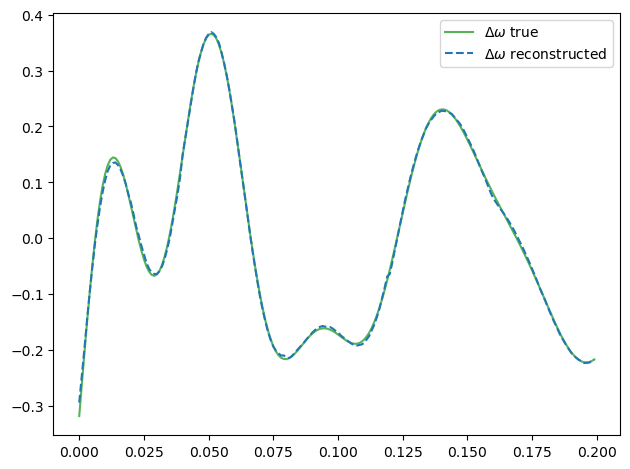

In [7]:
# --!--------------------------------------------------------------------------
# --! test individual results

with torch.no_grad():
    data_i  = 33
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    outs = model(timeseries, embedding_only=True)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_recon = torch.squeeze(outs[2], dim=0)

    t = np.arange(0., x_len*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# --!--------------------------------------------------------------------------
# --! save a trained embedding

savemod_on = True

if savemod_on:
    torch.save(model, 'data/models/care_embedding.pt')

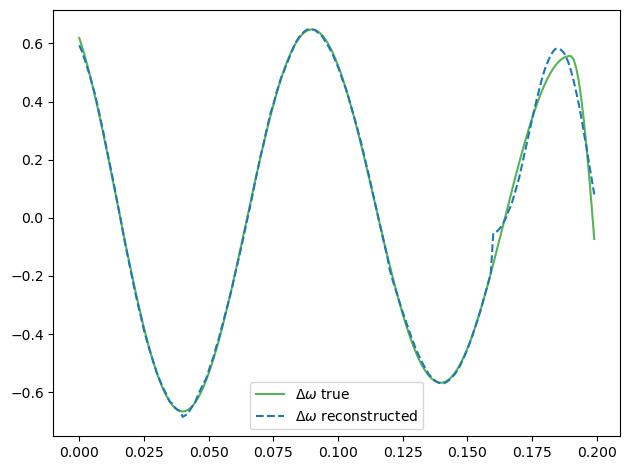

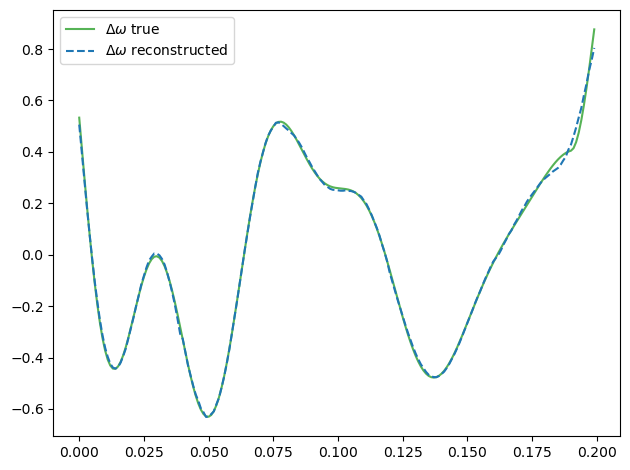

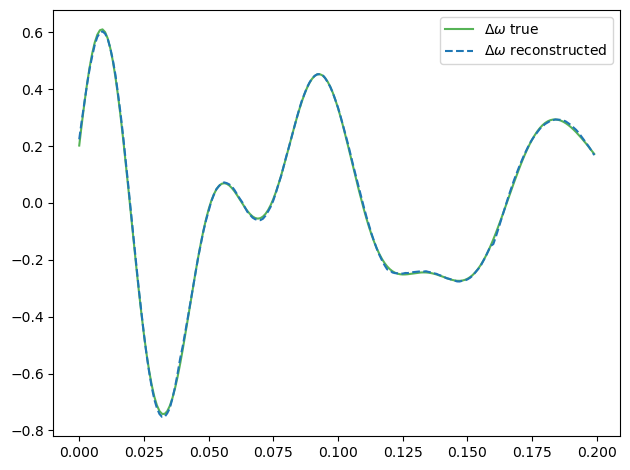

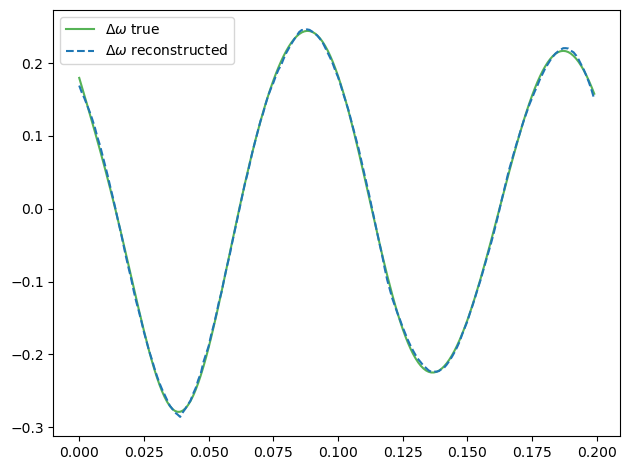

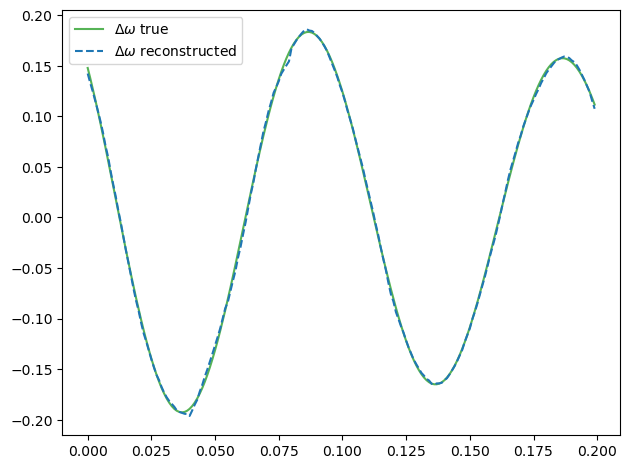

In [9]:
# --!--------------------------------------------------------------------------
# --! evaluate model on long timeseries

eval_ts_len       = 200
eval_timestep     = 0.001
eval_dataset_dir  = 'cavity/eval_10Hz_24Hz'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval1', eval_ts_len)

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for datum in data:
        datum = datum[:, :x_len, :1]
        outs = model(datum, embedding_only=True)

        timeseries       = torch.squeeze(datum, dim=0)
        timeseries_recon = torch.squeeze(outs[2], dim=0)

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep)

        plt.figure()
        plt.plot(t[:x_len], timeseries[:x_len, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
        plt.plot(t[:x_len], timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
        plt.legend()
        plt.tight_layout()
        plt.show()